In [ ]:
# Using pip (recommended)
#pip install seaborn

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("data.csv")
df.head()

,year,match_id,team,runs_scored,players,wickets_taken
0,2017,755,Delhi Capitals,236,"Player_2, Player_22, Player_85, Player_58, Pla...",6
1,2015,268,Gujarat Titans,61,"Player_68, Player_41, Player_77, Player_78, Pl...",8
2,2009,965,Delhi Capitals,69,"Player_17, Player_47, Player_99, Player_40, Pl...",5
3,2014,488,Gujarat Titans,96,"Player_93, Player_60, Player_41, Player_61, Pl...",2
4,2023,439,Kolkata Knight Riders,244,"Player_7, Player_9, Player_25, Player_42, Play...",0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   year           250 non-null    int64 
 1   match_id       250 non-null    int64 
 2   team           250 non-null    object
 3   runs_scored    250 non-null    int64 
 4   players        250 non-null    object
 5   wickets_taken  250 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 11.8+ KB


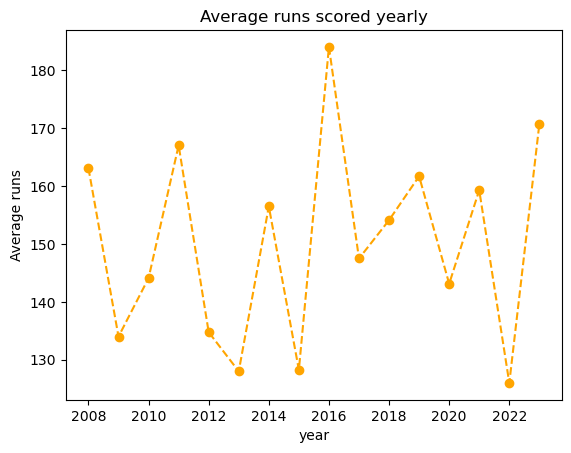

In [8]:
avg_score=df.groupby("year")["runs_scored"].mean()
plt.plot(avg_score.index,avg_score.values,marker="o",linestyle="--",color="orange")
plt.title("Average runs scored yearly")
plt.xlabel("year")
plt.ylabel("Average runs")
plt.show()

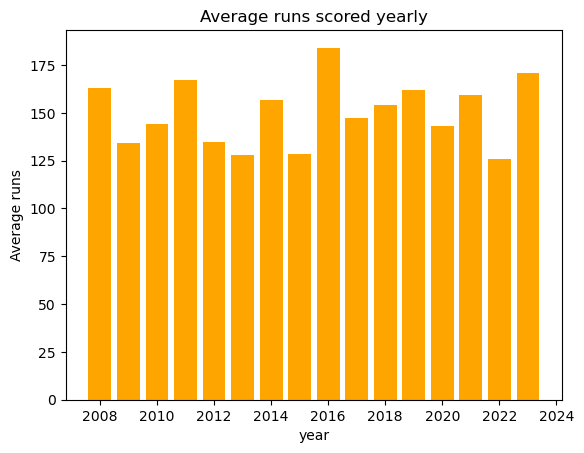

In [27]:
avg_score=df.groupby("year")["runs_scored"].mean()
plt.bar(avg_score.index,avg_score.values,color="orange")
plt.title("Average runs scored yearly")
plt.xlabel("year")
plt.ylabel("Average runs")
plt.show()

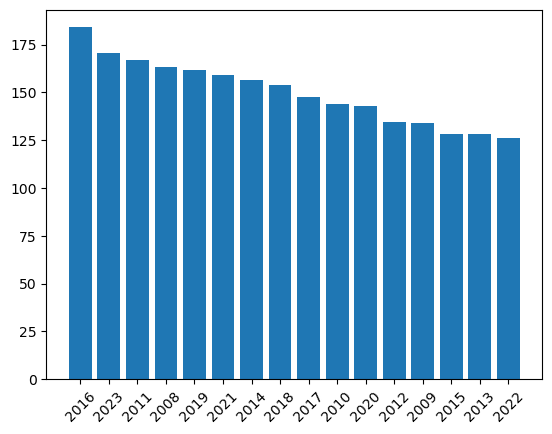

In [33]:
avg_score=df.groupby("year")["runs_scored"].mean().sort_values(ascending=False)
plt.bar(range(len(avg_score)),avg_score.values) # range(len(avg_score)) plots in sorted order
plt.xticks(range(len(avg_score)),avg_score.index,rotation=45) # xticks is assigning correct year labels
plt.show()

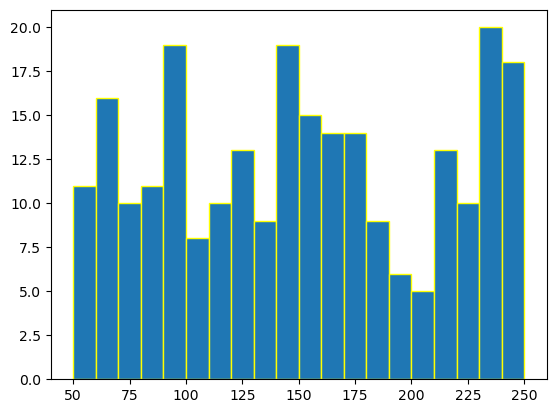

In [36]:
plt.hist(df["runs_scored"],bins=20,edgecolor="yellow")
plt.show()

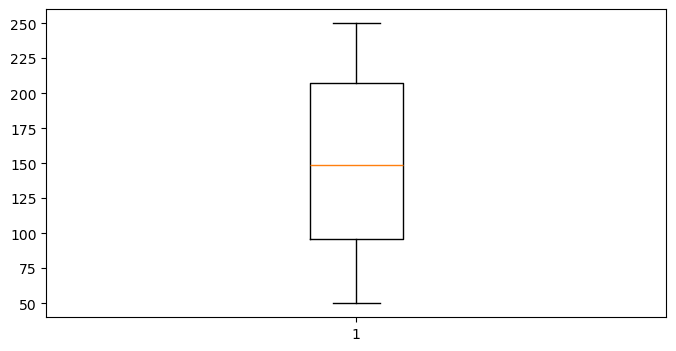

In [41]:
plt.figure(figsize=(8,4))
plt.boxplot(df["runs_scored"])
plt.show()

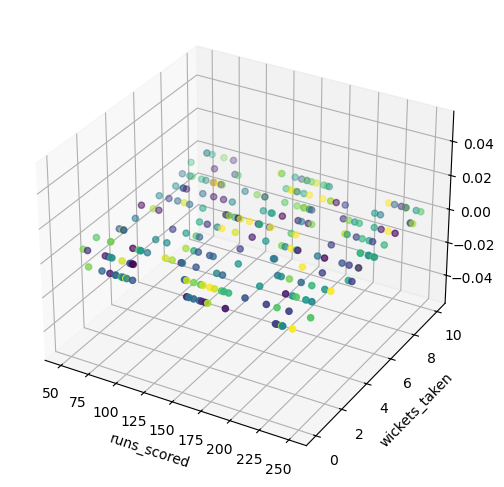

In [49]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(figsize=(6,7))
f=fig.add_subplot(projection='3d')
f.scatter(df["runs_scored"],df["wickets_taken"],c=df["year"])
f.set_xlabel("runs_scored")
f.set_ylabel("wickets_taken")
plt.show()

In [50]:
age_groups=["Children (0-18)","Adults (19-25)",
            "Adults (26-34)","Adults (35-54)",
            "Adults (55-64)","SENIORS (65+)"]
population=[75307800,277799100,
            39817700,81478600,
            42061700,52784400]

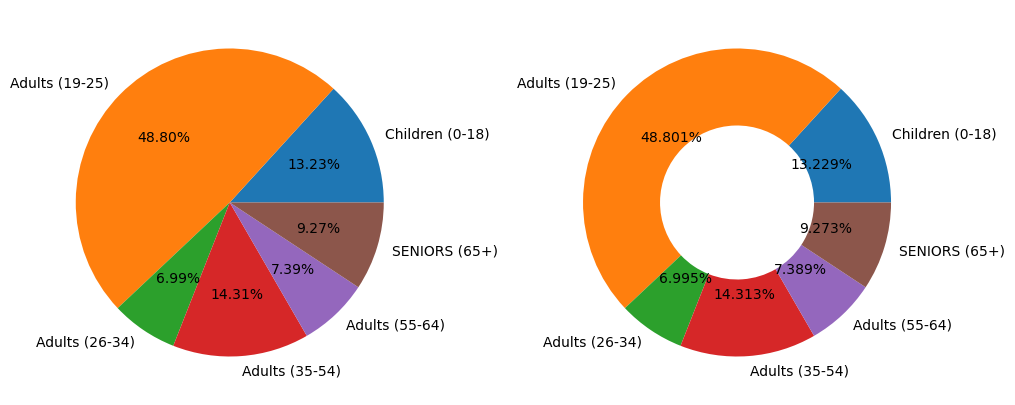

In [60]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
ax1.pie(population,labels=age_groups,autopct="%.2f%%")
ax2.pie(population,labels=age_groups,autopct="%.3f%%",wedgeprops=dict(width=0.5))
plt.show()

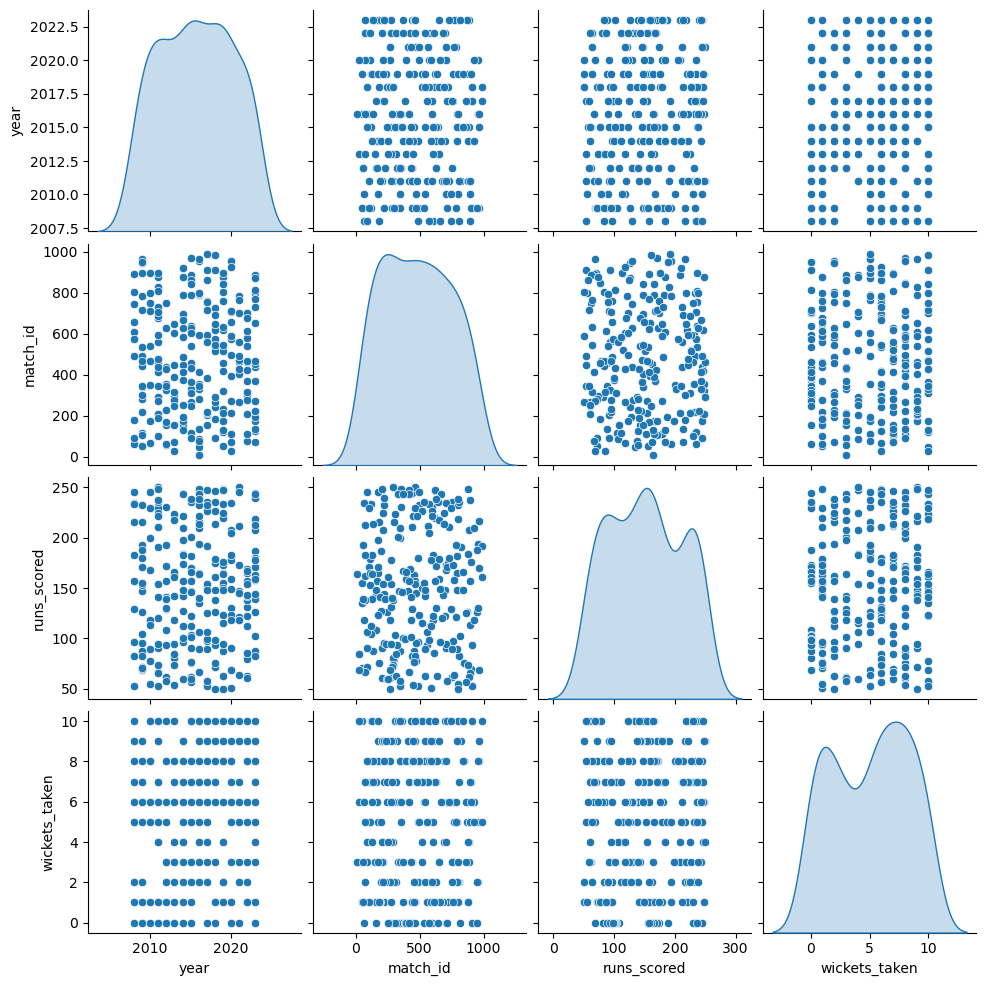

In [5]:
sns.pairplot(df,diag_kind="kde")

<Axes: >

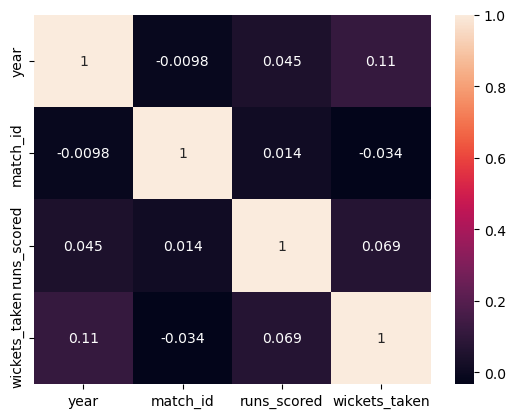

In [6]:
c=df.select_dtypes(["int","float"]).columns
sns.heatmap(df[c].corr(),annot=True)

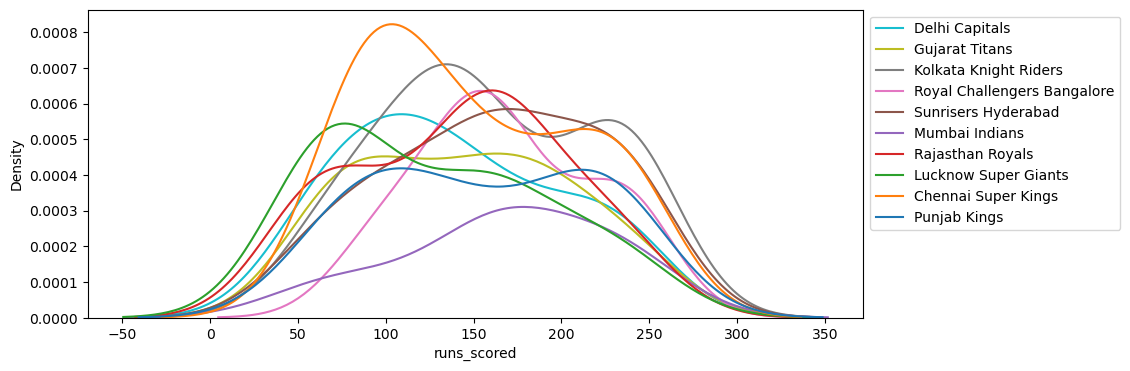

In [20]:
#
plt.figure(figsize=(10,4))
sns.kdeplot(df,x="runs_scored",hue="team")
plt.legend(df["team"].unique(),bbox_to_anchor=(1,1))
plt.show()

<Axes: xlabel='runs_scored', ylabel='Density'>

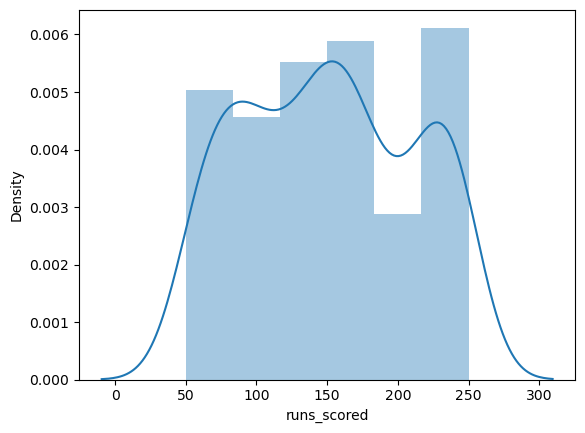

In [23]:
sns.distplot(df["runs_scored"])

<Axes: xlabel='runs_scored', ylabel='wickets_taken'>

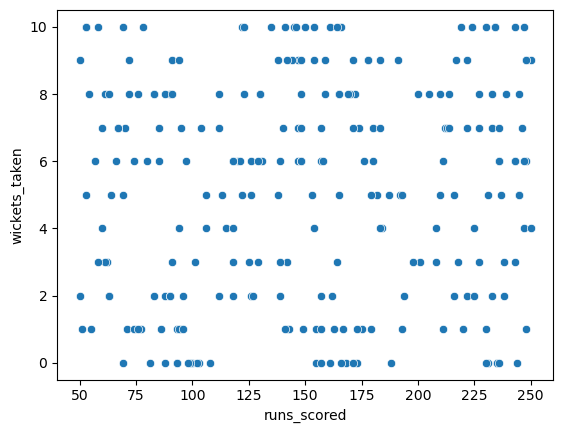

In [25]:
sns.scatterplot(data=df,x="runs_scored",y="wickets_taken")

<Axes: xlabel='runs_scored', ylabel='team'>

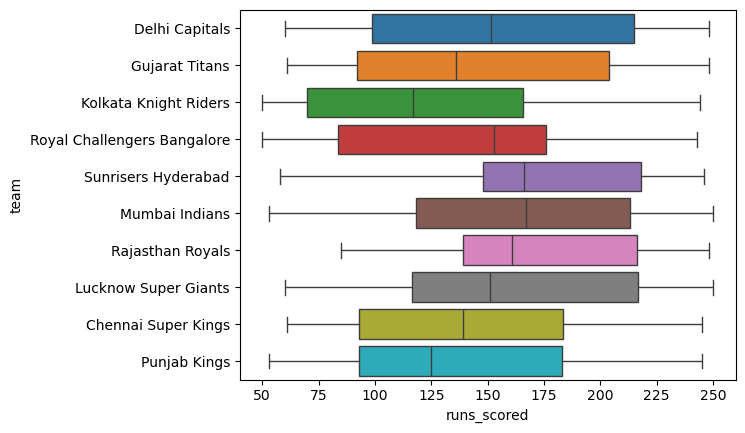

In [30]:
sns.boxplot(data=df,x="runs_scored",y="team",hue="team")
#sns.boxplot(df["runs_scored"])

<Figure size 600x400 with 0 Axes>

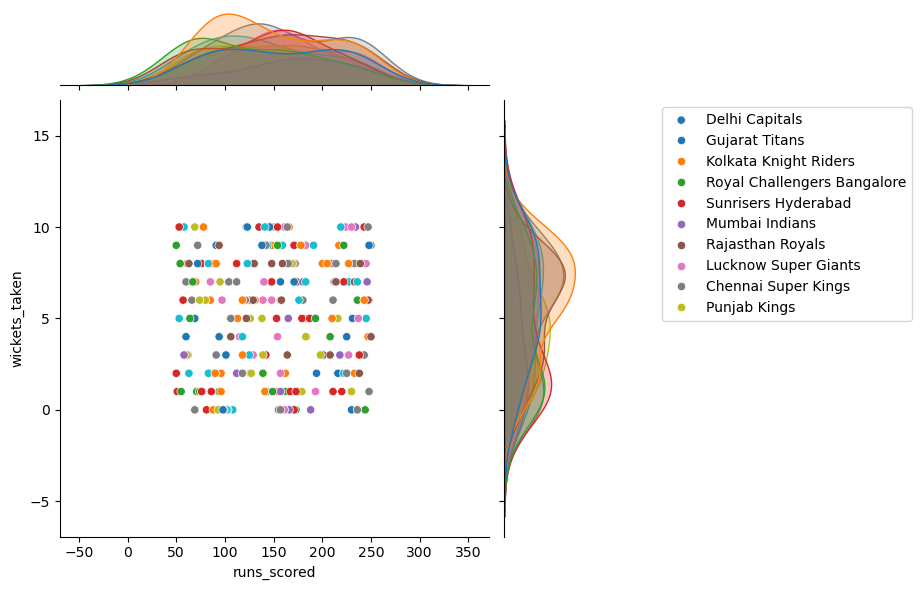

In [43]:
plt.figure(figsize=(6,4))
sns.jointplot(data=df,x="runs_scored",y="wickets_taken",hue="team")
plt.legend(df["team"].unique(),bbox_to_anchor=(2,1),loc="best")
plt.show()

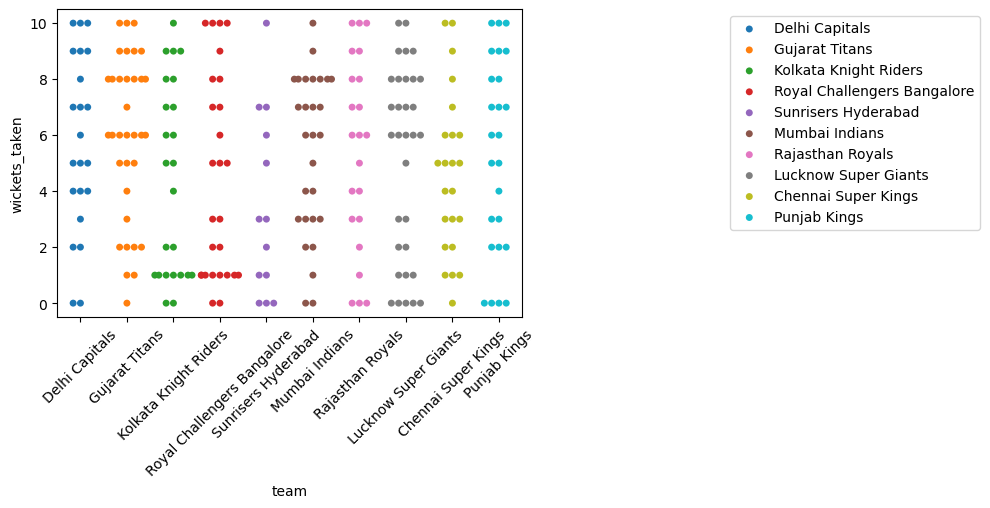

In [46]:
plt.figure(figsize=(6,4))
sns.swarmplot(data=df,x="team",y="wickets_taken",hue="team")
plt.legend(df["team"].unique(),bbox_to_anchor=(2,1),loc="best")
plt.xticks(rotation=45)
plt.show() # beeswarm

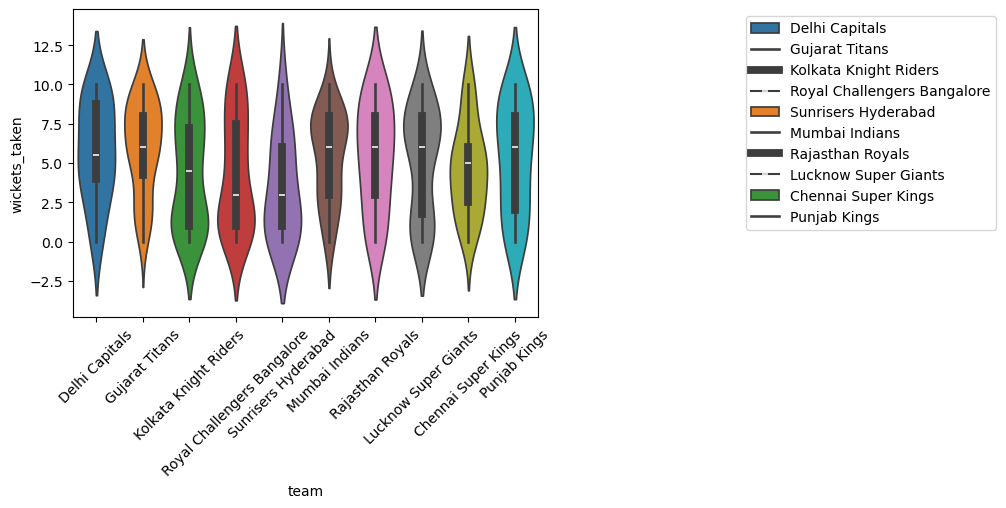

In [6]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df,x="team",y="wickets_taken",hue="team")
plt.legend(df["team"].unique(),bbox_to_anchor=(2,1),loc="best")
plt.xticks(rotation=45)
plt.show()

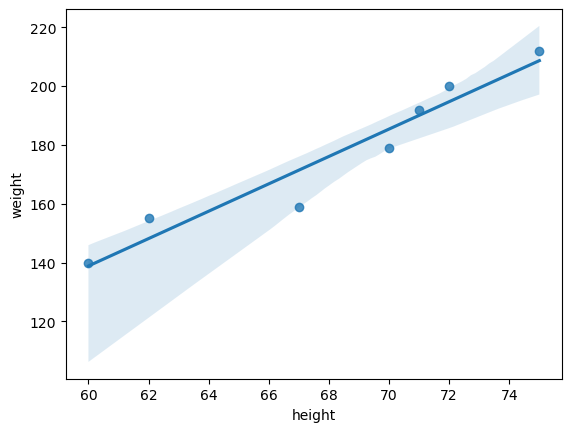

In [8]:
data={
    "weight":[140,155,159,179,192,200,212],
    "height":[60,62,67,70,71,72,75]
}
a=pd.DataFrame(data)
sns.regplot(data=a,x="height",y="weight")
plt.show()

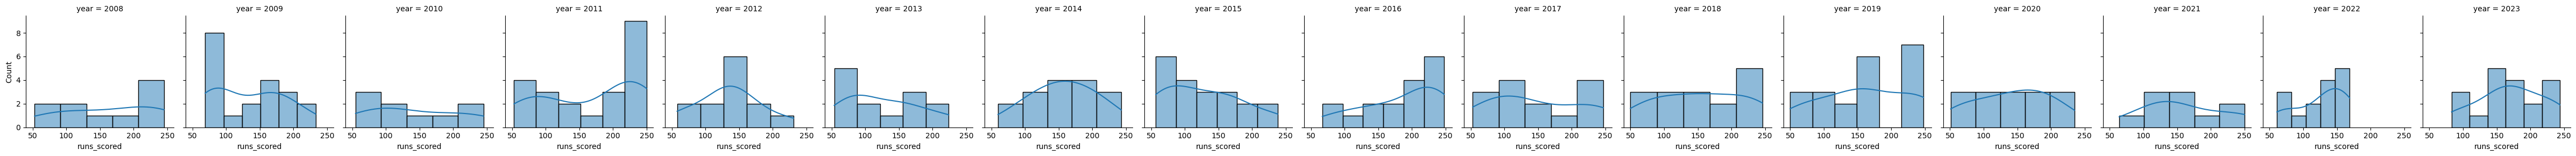

In [10]:
s=sns.FacetGrid(df,col="year")
s.map(sns.histplot,"runs_scored",kde=True)